# Examining how the pipeline performs with each detected combination.

- Let's examine one of each manually and make the pipeline work for them.
- 3sml: hd18256
- 2sm: hd10072
- 2ml: hd16673
- 1m: hd11131
- 0: hd10700

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize

import celerite2
from celerite2 import terms

from prettytable import PrettyTable

import sys
from pathlib import Path

sys.path.append(str(Path('../..').resolve()))

from helpers.df_ops import prepare_df, split_df, clean_df
from helpers.priors import find_classify_signals, get_priors

SEED = 1701
error_percent = 5




1/10
The best params were found for const with NLPD of -3.7594055232491725.
+--------+------+------------+-------------+
| sigma  |  Q   | rho (days) | rho (years) |
+--------+------+------------+-------------+
| 0.0001 | 0.06 |   304.06   |     0.83    |
+--------+------+------------+-------------+
2/10
The best params were found for 2ml with NLPD of -3.759779767544373.
+--------+-------+------------+-------------+
| sigma  |   Q   | rho (days) | rho (years) |
+--------+-------+------------+-------------+
| 0.0001 | 10.00 |   338.00   |     0.93    |
| 0.0001 |  5.01 |  39964.91  |    109.49   |
+--------+-------+------------+-------------+
3/10
The best params were found for const with NLPD of -3.7655135919426925.
+--------+------+------------+-------------+
| sigma  |  Q   | rho (days) | rho (years) |
+--------+------+------------+-------------+
| 0.0001 | 0.04 |  2518.93   |     6.90    |
+--------+------+------------+-------------+
4/10
The best params were found for 2ml with NLPD

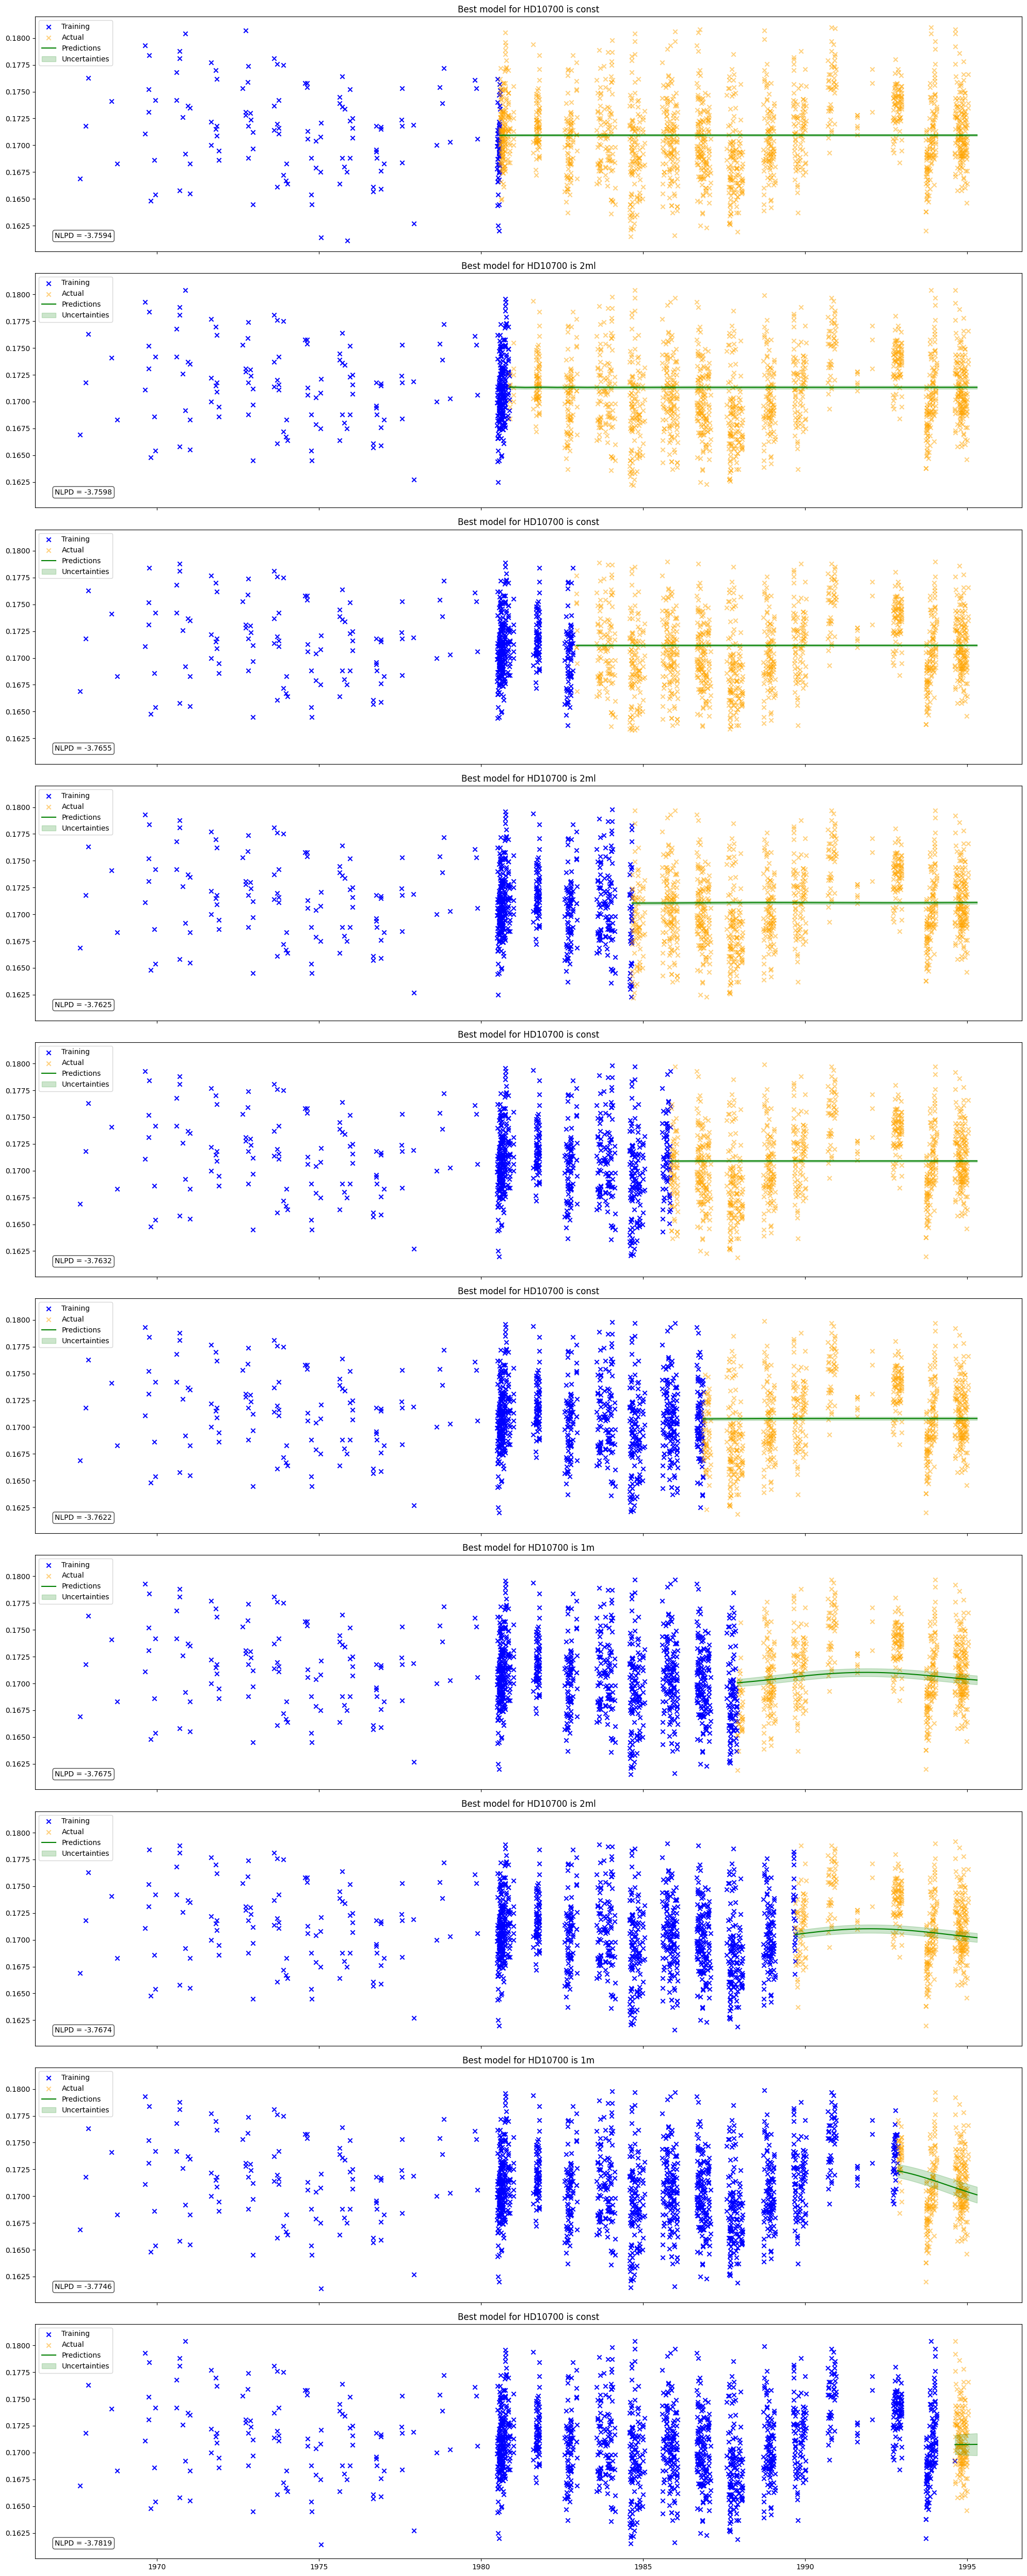

In [2]:
from helpers.gpr import train_gpr

datapath = r"../../Data/hd10700_caii.txt"
add_prefix = True
relative = True
train_split = 0.8
valid_split = 0.19

require_mid = True
sigma_upper_mult = 5
rho_bound_mults = [0.9, 1.1]
q_bounds_in = [5, 10]
loop_verbose = False
loop_plot = False
loop_savefigs = False
star_name = "HD10700"
star_type = "G"
results_verbose = True
results_plot = True
ax = None

# Window analysis using refactored train_gpr
def plot_moving_window(n_windows=10, train_low=0.1, train_high=0.9):
    fig, axes = plt.subplots(n_windows, 1, figsize=(20, 5 * n_windows), sharex=True, sharey=True)
    train_splits = np.linspace(train_low, train_high, n_windows)

    for idx, ts in enumerate(train_splits):
        print(f"{idx+1}/{n_windows}")
        train_gpr(
            datapath         = datapath,
            add_prefix       = add_prefix,
            relative         = relative,
            train_split      = ts,
            valid_split      = 0.99 - ts,
            star_name        = star_name,
            star_type        = star_type,
            error_percent    = error_percent,
            sigma_upper_mult = sigma_upper_mult,
            q_bounds_in      = q_bounds_in,
            require_mid      = require_mid,
            verbose          = False,
            plot             = False,
            loop_verbose     = loop_verbose,
            loop_plot        = loop_plot,
            loop_savefigs    = loop_savefigs,
            results_verbose  = results_verbose,
            results_plot     = results_plot,
            ax               = axes[idx],
            SEED             = SEED,
        )

    plt.tight_layout()
    plt.savefig(f"moving_window_{star_name}")
    plt.show()

plot_moving_window()


- Once again, I think it is important to introduce a factor of the model uncertainty using an MCMC.